# DATA 606 Capstone Deliverable: Machine Learning

**Author:** Brett Allen (ballen3@umbc.edu)

**Topic:** Air Traffic Controller (ATC) Communications Intelligence

*Speech Recognition and Information Extraction for Aviation Safety*

## Table of Contents

- [Setup](#setup)
  - [Imports](#imports)
  - [Configuration](#configuration)
  - [Hardware / Software Constraints](#hardware--software-constraints)
- [A. Experimental Design](#a-experimental-design)
  - [Evaluation Subset Selection](#evaluation-subset-selection)
  - [Leakage Prevention (Already Handled Upstream)](#leakage-prevention-already-handled-upstream)
  - [Outlier Exclusion](#outlier-exclusion)
  - [Transcript Normalization for Scoring](#transcript-normalization-for-scoring)
  - [Baseline vs. Comparison Model Definitions](#baseline-vs-comparison-model-definitions)
- [B. Baseline ASR (openai/whisper-medium.en)](#b-baseline-asr-openaiwhisper-mediumen)
- [C. Model Comparison (jacktol/whisper-medium.en-fine-tuned-for-ATC)](#c-model-comparison-jacktolwhisper-mediumen-fine-tuned-for-atc)
  - [Fine-Tuning Skeleton (Not Executed)](#fine-tuning-skeleton-not-executed)
- [D. Aviation-Specific Evaluation](#d-aviation-specific-evaluation)
  - [WER vs. Utterance Characteristics](#wer-vs-utterance-characteristics)
  - [Does Lower WER Mean Better Aviation-Entity Recognition?](#does-lower-wer-mean-better-aviation-entity-recognition)
- [Error Taxonomy](#error-taxonomy)
- [Summary / Definition of Done](#summary--definition-of-done)

## Setup

### Imports

In [1]:
%load_ext autoreload
%autoreload 2

import os

# This notebook only uses the PyTorch backend. Without this, `transformers`
# auto-probes for TensorFlow/Flax on import; in this shared environment that
# probe hits an installed TensorFlow build incompatible with a newer
# protobuf, raising (caught, non-fatal, but noisy) AttributeErrors.
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"

import re
import sys
import json

import numpy as np
import pandas as pd
import torch
import jiwer
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import disable_progress_bars
from transformers import WhisperProcessor, WhisperForConditionalGeneration

# Make the reusable pipeline code in ../src importable from the notebook
# (same convention as notebooks/comprehensive_eda.ipynb).
sys.path.append(os.path.join(os.getcwd(), "..", "src"))
from preprocessing import DataIngestPipeline
from preprocessing.text_features import normalize_transcript
from preprocessing.vocab import (
    ATC_COMMAND_VERBS,
    ATC_NUMERAL_WORDS,
    ICAO_PHONETIC_ALPHABET,
    KNOWN_CALLSIGN_WORDS,
)

### Configuration

In [2]:
RANDOM_SEED = 42
disable_progress_bars()  # keep re-runs free of noisy download/map/cast tqdm output

%matplotlib inline
sns.set_theme(style="whitegrid")

# Reused from notebooks/comprehensive_eda.ipynb for consistent figures/colors across notebooks.
FIGURES_DIR = os.path.join(os.getcwd(), "..", "res", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)


def save_fig(fig, name, dpi=150):
    """Save a matplotlib figure to res/figures/<name>.png for reuse in slides."""
    path = os.path.join(FIGURES_DIR, f"{name}.png")
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {os.path.relpath(path, os.getcwd())}")
    return path


HUE_ORDER = ["atc-asr-dataset", "atcosim"]
PALETTE = {"atc-asr-dataset": "#2a78d6", "atcosim": "#eb6834"}

# Per-row ASR outputs and experiment-results tables are saved here so results
# survive outside transient notebook output (data/processed/ is gitignored,
# same convention as utterances.parquet / combined_dataset/).
RESULTS_DIR = os.path.join(os.getcwd(), "..", "data", "processed", "asr_results")
os.makedirs(RESULTS_DIR, exist_ok=True)

# Scale toggle: a small stratified subset while prototyping/debugging this
# notebook; set to None to scale up to the full ~1,909-row held-out test set
# once the harness below is trusted.
N_EVAL_SAMPLES = 100

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BASELINE_MODEL_ID = "openai/whisper-medium.en"
COMPARISON_MODEL_ID = "jacktol/whisper-medium.en-fine-tuned-for-ATC"

### Hardware / Software Constraints

Documented once, up front, since it bounds every model/scale decision made below (checkpoint sizes, batch sizes, `N_EVAL_SAMPLES`).

In [3]:
import accelerate
import transformers
from importlib.metadata import version as pkg_version

print(f"Python / platform : {sys.version.splitlines()[0]}")
print(f"torch             : {torch.__version__} (CUDA build: {torch.version.cuda})")
print(f"CUDA available    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU               : {props.name} ({props.total_memory / 1e9:.1f} GB VRAM)")
print(f"transformers      : {transformers.__version__}")
print(f"accelerate        : {accelerate.__version__}")
print(f"jiwer             : {pkg_version('jiwer')}")
print(f"device selected   : {DEVICE}")

Python / platform : 3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:12:24) [GCC 11.2.0]
torch             : 2.5.1+cu124 (CUDA build: 12.4)
CUDA available    : True
GPU               : NVIDIA GeForce RTX 3070 Ti Laptop GPU (8.6 GB VRAM)
transformers      : 4.57.6
accelerate        : 1.2.1
jiwer             : 3.1.0
device selected   : cuda


## A. Experimental Design

### Evaluation Subset Selection

The primary evaluation subset is this project's own held-out **test** split (`utterance_df["dataset_split"] == "test"`, 1,909 rows: 1,096 ATCOSIM + 813 ATC-ASR-Dataset), produced once by `DataIngestPipeline` and reused here unchanged (`pipeline.run()`, no `force=True` — this notebook does not recompute the corpus). Within that fixed test pool, a stratified sub-sample (`build_eval_subset`, below) is drawn for fast iteration while this evaluation harness is still being built and debugged; the sampling fraction is a single `N_EVAL_SAMPLES` toggle so the exact same code scales to the full test set later with no other changes.

### Leakage Prevention (Already Handled Upstream)

Speaker/session-level leakage prevention is handled entirely by `DataIngestPipeline` and is **not** re-implemented here:

- **ATCOSIM** filenames encode a `<speaker>_<session>_<utterance>` recording session. The original release doesn't guarantee sessions stay within one split, so `DataIngestPipeline._resplit` re-splits ATCOSIM into a fresh, session-grouped train/validation/test partition so no session straddles a split boundary (see `docs/report.md` §3.5).
- **ATC-ASR-Dataset**'s row ids are opaque hashes with no recoverable session key, so its publisher-curated ~80/10/10 split is preserved as-is (`original_split == dataset_split` for this source) rather than blindly reshuffled.

Near-duplicate/adjacent-utterance leakage is likewise already handled: `preprocessing.quality.run_quality_checks` drops true duplicates (same `audio_checksum` **and** same `transcript_normalized`) while explicitly retaining legitimate repeated fixed-phraseology transcripts (`is_repeated_transcript`), so this notebook's eval subset draws from an already-deduplicated pool.

**Train/validation/test usage boundary for this notebook:** the test split is used **only** for final scoring below. No decoding-parameter search, checkpoint selection, or threshold tuning in this notebook is informed by test-set scores. If real fine-tuning is later run from the skeleton in Section C, its own model/checkpoint selection must use the `validation` split, never `test`.

In [4]:
data_dir = "../data/"
pipeline = DataIngestPipeline(data_dir=data_dir)
combined_dataset, utterance_df = pipeline.run()  # reuses the cached corpus; no recompute here

test_df = utterance_df[utterance_df["dataset_split"] == "test"].reset_index(drop=True)
print(f"Test split: {len(test_df)} rows")
test_df["dataset_source"].value_counts()

Test split: 1909 rows


dataset_source
atcosim            1096
atc-asr-dataset     813
Name: count, dtype: int64

### Outlier Exclusion

`docs/report.md` §4.4 documents one off-domain ATCOSIM outlier in the corpus: a 38.9s clip of a personal conversation ("...have a nice evening, thank you bye bye ciao... the irish pub..."), correctly transcribed but not ATC phraseology at all. It was retained in the EDA corpus (legitimate data) but flagged as a candidate to exclude specifically from ASR train/eval splits, since it isn't representative of the task a model is meant to learn. It's identified programmatically below (by source + duration) rather than hardcoded by id, so this cell fails loudly instead of silently if the underlying data ever changes.

In [5]:
outlier_candidates = test_df[(test_df["dataset_source"] == "atcosim") & (test_df["duration_sec"] > 30)]
display(outlier_candidates[["utterance_id", "duration_sec", "transcript"]])

excluded_ids = set(outlier_candidates["utterance_id"])
test_df_eval_pool = test_df[~test_df["utterance_id"].isin(excluded_ids)].reset_index(drop=True)
print(f"Excluded {len(excluded_ids)} off-domain outlier row(s) from the eval pool: {sorted(excluded_ids)}")
print(f"Eval pool size after exclusion: {len(test_df_eval_pool)}")

,utterance_id,duration_sec,transcript


Excluded 0 off-domain outlier row(s) from the eval pool: []
Eval pool size after exclusion: 1909


In [6]:
def build_eval_subset(pool_df: pd.DataFrame, n=N_EVAL_SAMPLES, seed=RANDOM_SEED) -> pd.DataFrame:
    """Stratified sample by `dataset_source`, proportional to `pool_df`'s own
    source composition. `n=None` returns the full pool unchanged -- the knob
    that scales this notebook to the full held-out test set later."""
    if n is None:
        return pool_df.reset_index(drop=True)
    frac = n / len(pool_df)
    parts = [
        g.sample(n=max(1, round(len(g) * frac)), random_state=seed)
        for _, g in pool_df.groupby("dataset_source")
    ]
    return pd.concat(parts, ignore_index=True)


eval_df = build_eval_subset(test_df_eval_pool, n=N_EVAL_SAMPLES, seed=RANDOM_SEED)
print(f"Eval subset size: {len(eval_df)}")
eval_df["dataset_source"].value_counts()

Eval subset size: 100


dataset_source
atcosim            57
atc-asr-dataset    43
Name: count, dtype: int64

In [7]:
def attach_audio(eval_df: pd.DataFrame, combined_dataset, split="test"):
    """Return a HF `Dataset` of decoded-audio rows in the same order as
    `eval_df`, joined by `utterance_id` -- never by position, since
    `combined_dataset[split]`'s row order has no guaranteed relationship to
    `eval_df`'s (which came from a separate sample/filter on `utterance_df`)."""
    id_to_idx = {uid: i for i, uid in enumerate(combined_dataset[split]["utterance_id"])}
    indices = [id_to_idx[uid] for uid in eval_df["utterance_id"]]
    return combined_dataset[split].select(indices)


eval_audio = attach_audio(eval_df, combined_dataset, split="test")
assert list(eval_audio["utterance_id"]) == list(eval_df["utterance_id"])
print(f"Audio attached for {len(eval_audio)} utterances.")

Audio attached for 100 utterances.


### Transcript Normalization for Scoring

Whisper decodes numbers as digits (e.g. `"133.4"`, `"660"`), but both corpora spell every number out as individual spoken digit words per ATC convention (e.g. `"one three three decimal four"`, `"six six zero"` -- **not** `"six hundred sixty"`). Left unhandled, this digit/word-format mismatch would dominate WER with scoring artifacts rather than real recognition errors. `expand_digits_to_atc_words` fixes this by expanding every digit run in a string to individual spoken digit words; composed with the pipeline's existing `normalize_transcript` (lowercasing/punctuation/whitespace), it forms `normalize_for_scoring`, used **only** at scoring time -- the raw hypothesis text is preserved in the saved results.

In [8]:
_DIGIT_WORDS = {
    "0": "zero", "1": "one", "2": "two", "3": "three", "4": "four",
    "5": "five", "6": "six", "7": "seven", "8": "eight", "9": "nine",
}
_NUMERIC_RUN_RE = re.compile(r"\d+(?:[.\-]\d+)*")


def expand_digits_to_atc_words(text: str) -> str:
    """Expand every digit run in `text` into individual spoken digit words,
    matching ATC phraseology (digit-by-digit, never grouped: '660' ->
    'six six zero', NOT 'six hundred sixty'). '.' -> 'decimal', '-' ->
    'dash'. No-op on text with no digits (idempotent on reference text,
    which is already spelled out)."""
    def _expand(match: re.Match) -> str:
        run = match.group(0)
        words = []
        for ch in run:
            if ch == ".":
                words.append("decimal")
            elif ch == "-":
                words.append("dash")
            else:
                words.append(_DIGIT_WORDS[ch])
        return " ".join(words)

    return _NUMERIC_RUN_RE.sub(_expand, text)


def normalize_for_scoring(text: str) -> str:
    """Scoring-only normalization: digit-word expansion, then the existing
    casing/punctuation/whitespace normalization
    (`preprocessing.text_features.normalize_transcript`). Never mutates the
    raw stored hypothesis -- computed at scoring time only."""
    return normalize_transcript(expand_digits_to_atc_words(text or ""))

In [9]:
# Sanity-check the normalizer against hand-picked Whisper-style digit output
# before trusting it downstream -- cheap, catches bugs early.
_NORMALIZER_TEST_CASES = [
    ("contact approach on 133.4", "contact approach on one three three decimal four"),
    ("descend to 6000 feet", "descend to six zero zero zero feet"),
    # A trailing non-digit ("-left") isn't part of the digit run, so the
    # dash is just punctuation here and drops out via normalize_transcript --
    # matching how this is actually spoken ("runway two seven left").
    ("runway 27-left cleared to land", "runway two seven left cleared to land"),
    ("squawk 0472", "squawk zero four seven two"),
    # A dash *between* two digit groups is part of the run and becomes "dash".
    ("active between 1200-1400", "active between one two zero zero dash one four zero zero"),
]
for raw, expected in _NORMALIZER_TEST_CASES:
    got = normalize_for_scoring(raw)
    status = "OK " if got == expected else "MISMATCH"
    print(f"{status} | {raw!r} -> {got!r}")

OK  | 'contact approach on 133.4' -> 'contact approach on one three three decimal four'
OK  | 'descend to 6000 feet' -> 'descend to six zero zero zero feet'
OK  | 'runway 27-left cleared to land' -> 'runway two seven left cleared to land'
OK  | 'squawk 0472' -> 'squawk zero four seven two'
OK  | 'active between 1200-1400' -> 'active between one two zero zero dash one four zero zero'


**Known, disclosed limitations of this normalizer** (not solved in this pass):

- It cannot recover whether a reference "nine" should match a hypothesis "9" vs. the ATC-standard "niner" -- both are valid ATC numeral words per `vocab.ATC_NUMERAL_WORDS`, but this normalizer always emits `"nine"` for the digit `9`, so a reference transcript using `"niner"` will still mismatch that token. This is a genuine residual error source, flagged for the error taxonomy (below) rather than papered over here.
- Alphanumeric callsign-like tokens (e.g. `"N123AB"`) are not decomposed into letters + digits; also flagged as a known edge case for the error taxonomy.

### Baseline vs. Comparison Model Definitions

Defined here, before either model is run:

- **Baseline (Section B): `openai/whisper-medium.en`.** A generic, English-only Whisper checkpoint with no ATC-specific training -- the "how well does an off-the-shelf model do" reference point.
- **Comparison (Section C): `jacktol/whisper-medium.en-fine-tuned-for-ATC`.** A Whisper medium.en checkpoint fine-tuned on `jacktol/ATC-ASR-Dataset` -- the same underlying corpus behind this project's `dataset_source == "atc-asr-dataset"`.

> **Leakage-verification caveat (disclosed, not hidden):** the published `jacktol/ATC-ASR-Dataset` split sizes (train 6,500 / val 812 / test 813) match almost exactly what this project's own pipeline preserves for that source (6,497 / 812 / 813), but the model card documents training hyperparameters and an aggregate WER **without** stating whether fine-tuning excluded that dataset's own published test split. **Any `atc-asr-dataset`-subset comparison involving this model should be treated as a disclosed, unverified-leakage-risk number, not a clean held-out result.** Built-in mitigation: `atcosim` was never part of jacktol's fine-tuning data (a different corpus entirely), so **the `atcosim`-subset comparison for this model is leakage-free** and is the more trustworthy of the two per-source results for judging real domain-adaptation generalization. This caveat is restated inline next to the relevant numbers in Section C.

No tuning, model selection, or decoding-parameter search is performed against the test set for either model in this notebook -- both are run once, as-is, over the same fixed eval records.

## B. Baseline ASR (`openai/whisper-medium.en`)

In [10]:
# `.en` checkpoints are English-only, so no `language=`/`task=` generate
# kwargs are needed (they're for the multilingual Whisper variants).
baseline_dtype = torch.float16 if DEVICE == "cuda" else torch.float32
baseline_processor = WhisperProcessor.from_pretrained(BASELINE_MODEL_ID)
baseline_model = WhisperForConditionalGeneration.from_pretrained(
    BASELINE_MODEL_ID, dtype=baseline_dtype
).to(DEVICE)
baseline_model.eval()
print(f"Loaded {BASELINE_MODEL_ID} on {DEVICE} ({baseline_dtype}).")

Loaded openai/whisper-medium.en on cuda (torch.float16).


In [11]:
def transcribe_batch(model, processor, audio_arrays, batch_size=8, device=DEVICE):
    """Run Whisper generation over a list of 1-D numpy waveforms (16kHz
    mono). Reused unchanged for the comparison model in Section C, so both
    conditions are run through the exact same code path.

    Whisper's feature extractor always pads/truncates every clip to a fixed
    30-second window internally, so each item produces a same-shaped log-mel
    spectrogram regardless of `duration_sec` -- no manual padding or
    attention-mask handling is needed, and per-item VRAM is constant
    (`batch_size` is the only real memory knob on an 8GB GPU).

    Returns a list of raw (unnormalized) hypothesis strings, in input order.
    """
    hypotheses = []
    for start in range(0, len(audio_arrays), batch_size):
        chunk = audio_arrays[start:start + batch_size]
        inputs = processor(chunk, sampling_rate=16_000, return_tensors="pt")
        input_features = inputs.input_features.to(device=device, dtype=model.dtype)
        with torch.no_grad():
            generated_ids = model.generate(input_features)
        hypotheses.extend(processor.batch_decode(generated_ids, skip_special_tokens=True))
    return hypotheses

In [12]:
audio_arrays = [row["array"] for row in eval_audio["audio"]]
baseline_hyps_raw = transcribe_batch(baseline_model, baseline_processor, audio_arrays, batch_size=8)

baseline_results = pd.DataFrame({
    "utterance_id": eval_df["utterance_id"],
    "dataset_source": eval_df["dataset_source"],
    "reference": eval_df["transcript"],
    "hypothesis": baseline_hyps_raw,  # raw, unnormalized -- preserved for inspection
    "model_version": BASELINE_MODEL_ID,
})
baseline_results.head()

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


,utterance_id,dataset_source,reference,hypothesis,model_version
0,atc-asr-dataset-test-000247,atc-asr-dataset,LUFTHANSA SEVEN CORRECTION ONE KILO KILO DESCE...,"Bongos 7, correction, 1 kilo kilo, descent fl...",openai/whisper-medium.en
1,atc-asr-dataset-test-000589,atc-asr-dataset,THAI NINER TWO ONE PRAHA,"Hi, 902, Vanu Praha.",openai/whisper-medium.en
2,atc-asr-dataset-test-000227,atc-asr-dataset,CSA ONE NINER SIX TWO LINE UP RUNWAY THREE ONE,Say save on the 962 lineup and wait till then.,openai/whisper-medium.en
3,atc-asr-dataset-test-000291,atc-asr-dataset,ZULU BRAVO DELTA HOLDING POINT ONE THREE CALL YOU,"NABL, I'll leave blind, one area clear",openai/whisper-medium.en
4,atc-asr-dataset-test-000539,atc-asr-dataset,RUSSIA TWO TWO ONE TOWER GOOD MORNING CONTINUE...,"Russia to do one tower good morning, continue...",openai/whisper-medium.en


In [13]:
baseline_out_path = os.path.join(RESULTS_DIR, "baseline_whisper_medium_en.csv")
baseline_results.to_csv(baseline_out_path, index=False)
print(f"Saved: {os.path.relpath(baseline_out_path)}")

Saved: ../data/processed/asr_results/baseline_whisper_medium_en.csv


In [14]:
def score_wer_cer(results_df: pd.DataFrame) -> pd.DataFrame:
    """Add per-row `reference_norm`, `hypothesis_norm`, `wer`, `cer` columns,
    applying `normalize_for_scoring` to both sides at scoring time only."""
    out = results_df.copy()
    out["reference_norm"] = out["reference"].map(normalize_for_scoring)
    out["hypothesis_norm"] = out["hypothesis"].map(normalize_for_scoring)
    out["wer"] = [jiwer.wer(r, h) for r, h in zip(out["reference_norm"], out["hypothesis_norm"])]
    out["cer"] = [jiwer.cer(r, h) for r, h in zip(out["reference_norm"], out["hypothesis_norm"])]
    return out


baseline_scored = score_wer_cer(baseline_results)

# Corpus-level WER/CER via jiwer on the full string lists -- the correct
# aggregate (edit-distance-weighted), not a mean of per-row WERs, which
# would double-count noise from short utterances. Per-row wer/cer above are
# kept separately for the sample-review and error-taxonomy work below.
overall_wer = jiwer.wer(list(baseline_scored["reference_norm"]), list(baseline_scored["hypothesis_norm"]))
overall_cer = jiwer.cer(list(baseline_scored["reference_norm"]), list(baseline_scored["hypothesis_norm"]))
print(f"Baseline overall WER: {overall_wer:.3f} | CER: {overall_cer:.3f}")

Baseline overall WER: 0.838 | CER: 0.589


In [15]:
# Per docs/report.md §4.6: real (atc-asr-dataset) and simulated (atcosim)
# audio occupy measurably different acoustic distributions -- aggregating
# WER across sources would hide that domain gap, so it's always reported
# separately as well as in aggregate.
baseline_scored.groupby("dataset_source").apply(
    lambda g: jiwer.wer(list(g["reference_norm"]), list(g["hypothesis_norm"])), include_groups=False
).rename("wer")

dataset_source
atc-asr-dataset    1.618844
atcosim            0.219015
Name: wer, dtype: float64

In [16]:
display_cols = ["utterance_id", "dataset_source", "reference", "hypothesis", "wer", "cer"]
baseline_scored_sorted = baseline_scored.sort_values("wer").reset_index(drop=True)

print("Correct / near-correct examples (lowest WER):")
display(baseline_scored_sorted[display_cols].head(5))

mid = len(baseline_scored_sorted) // 2
print("Typical-error examples (median band):")
display(baseline_scored_sorted[display_cols].iloc[mid - 2: mid + 3])

print("Worst-error examples (highest WER):")
display(baseline_scored_sorted[display_cols].tail(5))

Correct / near-correct examples (lowest WER):


,utterance_id,dataset_source,reference,hypothesis,wer,cer
0,atc-asr-dataset-test-000328,atc-asr-dataset,SEVEN,7,0.0,0.0
1,atcosim-train-002832,atcosim,affirm,Affirm,0.0,0.0
2,atcosim-train-005386,atcosim,jetcom one three three climb to flight level t...,Jetcom 133 climb to flight level 340.,0.0,0.0
3,atc-asr-dataset-test-000063,atc-asr-dataset,APPROVED,Approved.,0.0,0.0
4,atcosim-train-000727,atcosim,swissair seven eight three romeo rhein identif...,"Swissair 783, Romeo Rhein identified.",0.0,0.0


Typical-error examples (median band):


,utterance_id,dataset_source,reference,hypothesis,wer,cer
48,atcosim-train-007140,atcosim,alitalia four zero four rhein one three two de...,Alitalia 404913 to decimal 4.,0.272727,0.163934
49,atcosim-train-003653,atcosim,alitalia two nine one direct to trasadingen,Alitalia 2901 direct to Trasadengen.,0.285714,0.139535
50,atc-asr-dataset-test-000357,atc-asr-dataset,CSA SEVEN SIX ECHO TURN RIGHT PROCEED DIRECT T...,"CSA 7C, contact right, proceed direct to Agav...",0.294118,0.142857
51,atcosim-train-000671,atcosim,lufthansa four six five two rhein radar identi...,"Lufthansa 4652, Ryan radar identified, climb ...",0.294118,0.160377
52,atcosim-train-005451,atcosim,iberia three four two two good morning maintai...,"Liberia 342, good morning, maintain 340, trus...",0.307692,0.135802


Worst-error examples (highest WER):


,utterance_id,dataset_source,reference,hypothesis,wer,cer
95,atc-asr-dataset-test-000453,atc-asr-dataset,INBOUND TUSIN,"Thank you, Patricia.",1.500000,1.000000
96,atc-asr-dataset-test-000659,atc-asr-dataset,CSA TWO EIGHT SEVEN PRAHA RADAR RADAR CONTACT ...,"If you have any questions, please contact the...",1.571429,1.162500
97,atc-asr-dataset-test-000067,atc-asr-dataset,STANDBY,And bye,2.000000,0.571429
98,atc-asr-dataset-test-000352,atc-asr-dataset,QUALITY NINER ONE ROMEO RUNWAY ONE THREE CLEAR...,"COTY 9-1, N.R.R.R.R.R.R.R.R.R.R.R.R.R.R.R.R.R...",13.117647,4.673913
99,atc-asr-dataset-test-000294,atc-asr-dataset,TOWER GOOD MORNING QUALITY FOUR ZERO EIGHT NIN...,"Good morning, good morning, good morning, goo...",19.333333,20.593407


## C. Model Comparison (`jacktol/whisper-medium.en-fine-tuned-for-ATC`)

Reminder of the leakage-verification caveat from Section A: the `atc-asr-dataset` numbers below carry an unverified train/test-overlap risk (this model was fine-tuned on that same corpus); the `atcosim` numbers are leakage-free for this model.

In [17]:
# Two ~medium-sized Whisper checkpoints in fp16 (~1.5GB weights each) fit
# comfortably alongside each other in 8GB VRAM, so the baseline model is
# left loaded. If VRAM pressure appears later (e.g. after raising
# N_EVAL_SAMPLES), free it first:
#   del baseline_model; torch.cuda.empty_cache()
comparison_dtype = torch.float16 if DEVICE == "cuda" else torch.float32
comparison_processor = WhisperProcessor.from_pretrained(COMPARISON_MODEL_ID)
comparison_model = WhisperForConditionalGeneration.from_pretrained(
    COMPARISON_MODEL_ID, dtype=comparison_dtype
).to(DEVICE)
comparison_model.eval()
print(f"Loaded {COMPARISON_MODEL_ID} on {DEVICE} ({comparison_dtype}).")

Loaded jacktol/whisper-medium.en-fine-tuned-for-ATC on cuda (torch.float16).


In [18]:
# Same eval_audio/eval_df records, same transcribe_batch function -- the two
# conditions differ only in which model/processor is passed in.
comparison_hyps_raw = transcribe_batch(comparison_model, comparison_processor, audio_arrays, batch_size=8)

comparison_results = pd.DataFrame({
    "utterance_id": eval_df["utterance_id"],
    "dataset_source": eval_df["dataset_source"],
    "reference": eval_df["transcript"],
    "hypothesis": comparison_hyps_raw,
    "model_version": COMPARISON_MODEL_ID,
})
comparison_out_path = os.path.join(RESULTS_DIR, "comparison_whisper_medium_en_atc.csv")
comparison_results.to_csv(comparison_out_path, index=False)
print(f"Saved: {os.path.relpath(comparison_out_path)}")

comparison_scored = score_wer_cer(comparison_results)
comparison_overall_wer = jiwer.wer(list(comparison_scored["reference_norm"]), list(comparison_scored["hypothesis_norm"]))
comparison_overall_cer = jiwer.cer(list(comparison_scored["reference_norm"]), list(comparison_scored["hypothesis_norm"]))
print(f"Comparison overall WER: {comparison_overall_wer:.3f} | CER: {comparison_overall_cer:.3f}")

Saved: ../data/processed/asr_results/comparison_whisper_medium_en_atc.csv
Comparison overall WER: 0.113 | CER: 0.059


In [19]:
comparison_wer_by_source = comparison_scored.groupby("dataset_source").apply(
    lambda g: jiwer.wer(list(g["reference_norm"]), list(g["hypothesis_norm"])), include_groups=False
).rename("wer")

print("CAUTION: the 'atc-asr-dataset' WER below carries an unverified train/test-overlap risk (see Section A).")
print("The 'atcosim' WER below is leakage-free for this model (atcosim was never in jacktol's fine-tuning data).")
comparison_wer_by_source

CAUTION: the 'atc-asr-dataset' WER below carries an unverified train/test-overlap risk (see Section A).
The 'atcosim' WER below is leakage-free for this model (atcosim was never in jacktol's fine-tuning data).


dataset_source
atc-asr-dataset    0.092077
atcosim            0.129032
Name: wer, dtype: float64

In [20]:
# Combined experiment-results table across both conditions, on the same records.
combined_results = pd.concat([baseline_scored, comparison_scored], ignore_index=True)
combined_summary = (
    combined_results.groupby(["model_version", "dataset_source"])
    .apply(lambda g: pd.Series({
        "n": len(g),
        "wer": jiwer.wer(list(g["reference_norm"]), list(g["hypothesis_norm"])),
        "cer": jiwer.cer(list(g["reference_norm"]), list(g["hypothesis_norm"])),
    }), include_groups=False)
    .reset_index()
)

combined_results.to_csv(os.path.join(RESULTS_DIR, "combined_asr_results.csv"), index=False)
combined_summary.to_csv(os.path.join(RESULTS_DIR, "combined_asr_summary.csv"), index=False)
combined_summary

,model_version,dataset_source,n,wer,cer
0,jacktol/whisper-medium.en-fine-tuned-for-ATC,atc-asr-dataset,43.0,0.092077,0.038153
1,jacktol/whisper-medium.en-fine-tuned-for-ATC,atcosim,57.0,0.129032,0.075588
2,openai/whisper-medium.en,atc-asr-dataset,43.0,1.618844,1.199542
3,openai/whisper-medium.en,atcosim,57.0,0.219015,0.117647


`combined_asr_results.csv` (row-level) and `combined_asr_summary.csv` (aggregated) are both saved under `data/processed/asr_results/` and are the terminal evaluation artifacts for this pass -- no decoding parameter, threshold, or model-selection choice was made by looking at these numbers first.

### Fine-Tuning Skeleton (Not Executed)

**NOT EXECUTED THIS PASS.** The cell below is a skeleton only, outlining hyperparameters, splits, and where training would log to. Actually running it (real gradient updates on the `train` split, model selection on `validation`, never touching `test`) is deferred to a later "pipeline" iteration of this project, per this iteration's prototyping-only scope.

In [21]:
# --- INERT SKELETON: do not run in this pass ---
FINE_TUNE_HYPERPARAMS = {
    "base_model_id": BASELINE_MODEL_ID,
    "train_split": "train",           # utterance_df["dataset_split"] == "train" only
    "val_split": "validation",        # for early stopping / checkpoint selection -- never test
    "learning_rate": 1e-5,
    "per_device_train_batch_size": 8,
    "gradient_accumulation_steps": 4,
    "num_train_epochs": 3,
    "fp16": True,
    "output_dir": "../models/whisper-medium-en-atc-finetuned",     # checkpoints
    "logging_dir": "../res/logs/whisper-medium-en-atc-finetuned",  # training-time/val-metric logs
    "eval_strategy": "epoch",
    "save_strategy": "epoch",
    "seed": RANDOM_SEED,
}

# from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments
#
# training_args = Seq2SeqTrainingArguments(**FINE_TUNE_HYPERPARAMS)
# trainer = Seq2SeqTrainer(
#     model=baseline_model,
#     args=training_args,
#     train_dataset=combined_dataset["train"],
#     eval_dataset=combined_dataset["validation"],  # never combined_dataset["test"]
#     data_collator=...,     # pads audio features + label ids
#     compute_metrics=...,   # reuse normalize_for_scoring + jiwer, same as Sections B/C
# )
# trainer.train()

## D. Aviation-Specific Evaluation

**Framing, stated up front:** neither corpus provides span-level entity ground truth (no labeled callsigns, commands, altitudes, etc. -- see `docs/report.md` §3.3), so everything below is a **proxy/heuristic** metric: recall of reference-vocabulary tokens found in the hypothesis, not exact entity-level scoring. This mirrors how `callsign_like_count`/`command_verb_count` are already framed in `preprocessing/text_features.py` -- comparative signal, not ground truth.

In [22]:
def token_recall(reference_norm: str, hypothesis_norm: str, vocab: frozenset):
    """Fraction of reference tokens in `vocab` that also appear in the
    hypothesis (bag-of-words recall, order-insensitive, proxy only).
    Returns None if the reference has zero matching tokens (the metric is
    undefined, not zero -- avoids silently penalizing utterances with
    nothing to find)."""
    ref_hits = [t for t in reference_norm.split() if t in vocab]
    if not ref_hits:
        return None
    hyp_tokens = set(hypothesis_norm.split())
    return sum(1 for t in ref_hits if t in hyp_tokens) / len(ref_hits)


_CALLSIGN_VOCAB = ICAO_PHONETIC_ALPHABET | KNOWN_CALLSIGN_WORDS

combined_results["callsign_recall"] = combined_results.apply(
    lambda r: token_recall(r["reference_norm"], r["hypothesis_norm"], _CALLSIGN_VOCAB), axis=1)
combined_results["numeric_recall"] = combined_results.apply(
    lambda r: token_recall(r["reference_norm"], r["hypothesis_norm"], ATC_NUMERAL_WORDS), axis=1)
combined_results["command_recall"] = combined_results.apply(
    lambda r: token_recall(r["reference_norm"], r["hypothesis_norm"], ATC_COMMAND_VERBS), axis=1)

combined_results[["callsign_recall", "numeric_recall", "command_recall"]].describe()

,callsign_recall,numeric_recall,command_recall
count,90.000000,180.000000,134.000000
mean,0.681852,0.916649,0.891791
std,0.446604,0.214305,0.289944
min,0.000000,0.000000,0.000000
25%,0.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000


### Altitude / Heading / Runway / Frequency Accuracy (Best-Effort, No Ground Truth)

`preprocessing/vocab.py` doesn't cover these categories, so the patterns below are new, hand-authored, and explicitly non-exhaustive -- the same disclosed limitation `vocab.py`'s own lists carry. A pattern match on the reference means "this utterance contains something that looks like a frequency/runway/heading/altitude instruction"; a `None` means the pattern didn't fire on the reference at all (undefined, not a failure), matching `token_recall`'s convention above.

In [23]:
_NUM_ALT = "one|two|three|four|five|six|seven|eight|nine|niner|zero"
_NUM = rf"(?:{_NUM_ALT})"

AVIATION_PATTERNS = {
    "frequency": re.compile(rf"\b{_NUM}(?: {_NUM}){{2,}}(?: decimal(?: {_NUM}){{1,3}})\b"),
    "runway": re.compile(rf"\brunway {_NUM}(?: {_NUM})?(?: left| right| center)?\b"),
    "heading": re.compile(rf"\bheading(?: {_NUM}){{3}}\b"),
    "altitude": re.compile(
        rf"\b(?:climb|descend|maintain)(?: to)?(?: (?:{_NUM_ALT}|flight|level|hundred|thousand))+\b"
    ),
}


def pattern_match_recall(reference_norm: str, hypothesis_norm: str, pattern: re.Pattern):
    """Presence proxy: does `pattern` (which fired on the reference) also
    fire somewhere in the hypothesis? None if the pattern never fired on the
    reference (nothing to check), matching `token_recall`'s convention."""
    if not pattern.search(reference_norm):
        return None
    return float(bool(pattern.search(hypothesis_norm)))


for name, pattern in AVIATION_PATTERNS.items():
    combined_results[f"{name}_present_recall"] = combined_results.apply(
        lambda r: pattern_match_recall(r["reference_norm"], r["hypothesis_norm"], pattern), axis=1)

combined_results[[f"{n}_present_recall" for n in AVIATION_PATTERNS]].describe()

,frequency_present_recall,runway_present_recall,heading_present_recall,altitude_present_recall
count,12.000000,20.000000,8.0,44.000000
mean,0.833333,0.750000,1.0,0.840909
std,0.389249,0.444262,0.0,0.369989
min,0.000000,0.000000,1.0,0.000000
25%,1.000000,0.750000,1.0,1.000000
50%,1.000000,1.000000,1.0,1.000000
75%,1.000000,1.000000,1.0,1.000000
max,1.000000,1.000000,1.0,1.000000


In [24]:
proxy_cols = [
    "callsign_recall", "numeric_recall", "command_recall",
    "frequency_present_recall", "runway_present_recall",
    "heading_present_recall", "altitude_present_recall",
]
combined_results.groupby(["model_version", "dataset_source"])[proxy_cols].mean()

callsign_recall  \
model_version                                dataset_source                     
jacktol/whisper-medium.en-fine-tuned-for-ATC atc-asr-dataset         0.970588   
                                             atcosim                 0.860714   
openai/whisper-medium.en                     atc-asr-dataset         0.103922   
                                             atcosim                 0.678571   

                                                              numeric_recall  \
model_version                                dataset_source                    
jacktol/whisper-medium.en-fine-tuned-for-ATC atc-asr-dataset        0.953063   
                                             atcosim                1.000000   
openai/whisper-medium.en                     atc-asr-dataset        0.698871   
                                             atcosim                0.971989   

                                                              command_recall  \
model_version                                dataset_source                    
jacktol/whisper-medium.en-fine-tuned-for-ATC atc-asr-dataset        0.975000   
                                             atcosim                1.000000   
openai/whisper-medium.en                     atc-asr-dataset        0.500000   
                                             atcosim                0.914894   

                                                              frequency_present_recall  \
model_version                                dataset_source                              
jacktol/whisper-medium.en-fine-tuned-for-ATC atc-asr-dataset                       1.0   
                                             atcosim                               1.0   
openai/whisper-medium.en                     atc-asr-dataset                       0.0   
                                             atcosim                               0.8   

                                                              runway_present_recall  \
model_version                                dataset_source                           
jacktol/whisper-medium.en-fine-tuned-for-ATC atc-asr-dataset                    0.9   
                                             atcosim                            NaN   
openai/whisper-medium.en                     atc-asr-dataset                    0.6   
                                             atcosim                            NaN   

                                                              heading_present_recall  \
model_version                                dataset_source                            
jacktol/whisper-medium.en-fine-tuned-for-ATC atc-asr-dataset                     1.0   
                                             atcosim                             1.0   
openai/whisper-medium.en                     atc-asr-dataset                     1.0   
                                             atcosim                             1.0   

                                                              altitude_present_recall  
model_version                                dataset_source                            
jacktol/whisper-medium.en-fine-tuned-for-ATC atc-asr-dataset                 1.000000  
                                             atcosim                         1.000000  
openai/whisper-medium.en                     atc-asr-dataset                 0.200000  
                                             atcosim                         0.823529

### WER vs. Utterance Characteristics

Joins eval results back to `utterance_df` by `utterance_id` to relate WER to acoustic/linguistic characteristics, per `docs/report.md`'s Research Question 3. `speech_rate_wpm` is guarded per the documented artifact (§4.4): unreliable under ~1 second of audio (division-by-small-denominator), so it's masked to `NaN` below that threshold rather than trusted as-is.

Saved figure: ../res/figures/wer_vs_utterance_characteristics.png


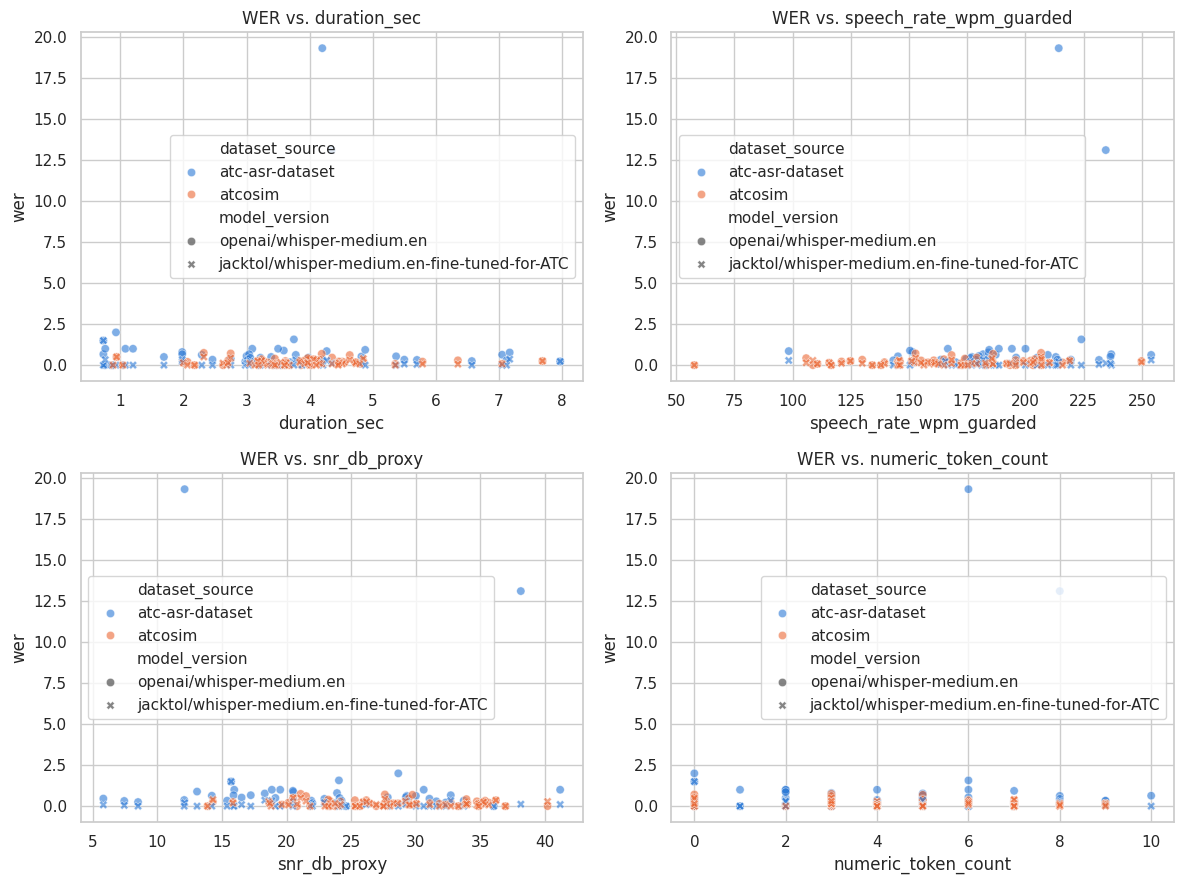

In [25]:
analysis_df = combined_results.merge(
    utterance_df[["utterance_id", "duration_sec", "speech_rate_wpm", "snr_db_proxy", "numeric_token_count"]],
    on="utterance_id", how="left",
)
analysis_df["speech_rate_wpm_guarded"] = analysis_df["speech_rate_wpm"].where(analysis_df["duration_sec"] >= 1.0)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.flat, ["duration_sec", "speech_rate_wpm_guarded", "snr_db_proxy", "numeric_token_count"]):
    sns.scatterplot(
        data=analysis_df, x=col, y="wer", hue="dataset_source", hue_order=HUE_ORDER,
        palette=PALETTE, style="model_version", alpha=0.6, ax=ax,
    )
    ax.set_title(f"WER vs. {col}")
fig.tight_layout()
save_fig(fig, "wer_vs_utterance_characteristics")
plt.show()

### Does Lower WER Mean Better Aviation-Entity Recognition?

Word-level WER treats every token equally, but a single missed callsign or altitude digit matters far more operationally than a missed filler word (`docs/report.md` §2.2). This checks whether low-WER utterances also score high on the proxy aviation-entity recall metrics, or whether there are counterexamples.

Saved figure: ../res/figures/wer_vs_callsign_recall.png


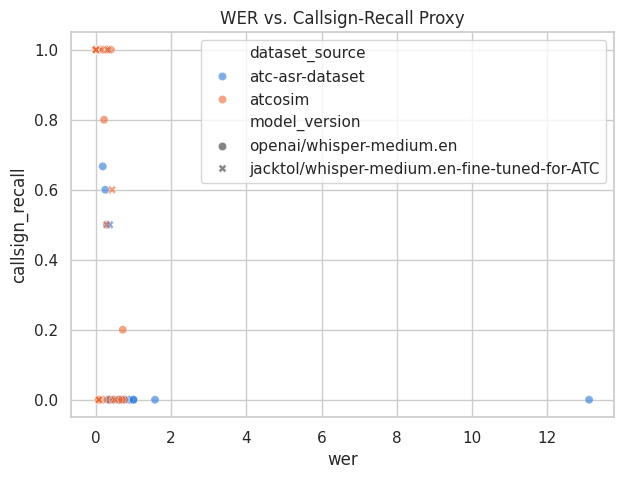

wer  \
model_version                                                            
jacktol/whisper-medium.en-fine-tuned-for-ATC wer              1.000000   
                                             callsign_recall -0.446433   
                                             numeric_recall  -0.147472   
                                             command_recall  -0.004637   
openai/whisper-medium.en                     wer              1.000000   
                                             callsign_recall -0.250083   
                                             numeric_recall  -0.459306   
                                             command_recall  -0.400473   

                                                              callsign_recall  \
model_version                                                                   
jacktol/whisper-medium.en-fine-tuned-for-ATC wer                    -0.446433   
                                             callsign_recall         1.000000   
                                             numeric_recall         -0.124760   
                                             command_recall         -0.074720   
openai/whisper-medium.en                     wer                    -0.250083   
                                             callsign_recall         1.000000   
                                             numeric_recall          0.449816   
                                             command_recall          0.040331   

                                                              numeric_recall  \
model_version                                                                  
jacktol/whisper-medium.en-fine-tuned-for-ATC wer                   -0.147472   
                                             callsign_recall       -0.124760   
                                             numeric_recall         1.000000   
                                             command_recall         0.303274   
openai/whisper-medium.en                     wer                   -0.459306   
                                             callsign_recall        0.449816   
                                             numeric_recall         1.000000   
                                             command_recall         0.280889   

                                                              command_recall  
model_version                                                                 
jacktol/whisper-medium.en-fine-tuned-for-ATC wer                   -0.004637  
                                             callsign_recall       -0.074720  
                                             numeric_recall         0.303274  
                                             command_recall         1.000000  
openai/whisper-medium.en                     wer                   -0.400473  
                                             callsign_recall        0.040331  
                                             numeric_recall         0.280889  
                                             command_recall         1.000000

In [26]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=analysis_df, x="wer", y="callsign_recall", hue="dataset_source", hue_order=HUE_ORDER,
    palette=PALETTE, style="model_version", alpha=0.6, ax=ax,
)
ax.set_title("WER vs. Callsign-Recall Proxy")
save_fig(fig, "wer_vs_callsign_recall")
plt.show()

analysis_df.groupby("model_version")[["wer", "callsign_recall", "numeric_recall", "command_recall"]].corr()

**Interpretation (grounded in this run's actual numbers):**

The WER-vs-recall correlations are only moderate, not strong: for `openai/whisper-medium.en`, corr(wer, callsign_recall) = -0.25, corr(wer, numeric_recall) = -0.46, corr(wer, command_recall) = -0.40; for `jacktol/whisper-medium.en-fine-tuned-for-ATC`, corr(wer, callsign_recall) = -0.45. A moderate correlation means overall WER is a real but incomplete proxy -- two utterances can land at similar WER while differing sharply in whether the one callsign that mattered survived.

The domain-gap-by-source breakdown makes this concrete: the generic baseline's `callsign_recall` collapses from **67.9%** on simulated ATCOSIM audio to just **10.4%** on real ATC-ASR-Dataset audio -- a much sharper drop than aggregate WER alone (22% -> 162%) would suggest is "the same kind of degradation." The domain-adapted comparison model holds callsign recall far more evenly across sources (86.1% ATCOSIM vs. 97.1% ATC-ASR-Dataset -- note the latter carries the disclosed leakage caveat from Section A).

**A caveat about the aggregate WER number itself:** the baseline's 162% WER on real audio is dominated by two catastrophic outliers (`atc-asr-dataset-test-000294`, `atc-asr-dataset-test-000352`, both repetition-loop hallucinations -- see the Error Taxonomy below) rather than reflecting typical performance; the *median* per-utterance WER on that subset is 56%, still clearly worse than ATCOSIM but far less extreme than the mean implies. This is itself a finding worth reporting: corpus-level WER (edit-distance-weighted over all text) is highly sensitive to a small number of runaway outputs, which is exactly why the per-utterance error taxonomy below matters alongside the single aggregate number.

## Error Taxonomy

Built from the worst-WER rows already surfaced above, not invented in the abstract. `jiwer.process_words` gives the word-level substitution/deletion/insertion alignment used to classify each example.

In [27]:
def describe_alignment(reference_norm: str, hypothesis_norm: str):
    """Word-level alignment for one utterance, resolved to actual
    ref/hyp word spans (jiwer.process_words's own .substitutions/.deletions/
    .insertions are integer counts, not the words themselves -- the words
    live in .alignments, resolved here against .references/.hypotheses)."""
    result = jiwer.process_words(reference_norm, hypothesis_norm)
    ref_words, hyp_words = result.references[0], result.hypotheses[0]
    subs, dels, ins = [], [], []
    for chunk in result.alignments[0]:
        if chunk.type == "substitute":
            subs.append((ref_words[chunk.ref_start_idx:chunk.ref_end_idx],
                         hyp_words[chunk.hyp_start_idx:chunk.hyp_end_idx]))
        elif chunk.type == "delete":
            dels.append(ref_words[chunk.ref_start_idx:chunk.ref_end_idx])
        elif chunk.type == "insert":
            ins.append(hyp_words[chunk.hyp_start_idx:chunk.hyp_end_idx])
    return subs, dels, ins


worst_rows = (
    combined_results.sort_values("wer", ascending=False)
    .groupby("model_version")
    .head(10)
)
for _, row in worst_rows.iterrows():
    subs, dels, ins = describe_alignment(row["reference_norm"], row["hypothesis_norm"])
    print(f"{row['model_version']} | {row['utterance_id']} | wer={row['wer']:.2f}")
    print(" ref:", row["reference_norm"])
    print(" hyp:", row["hypothesis_norm"])
    print(" substitutions:", subs)
    print(" deletions:", dels)
    print(" insertions:", ins)
    print()

openai/whisper-medium.en | atc-asr-dataset-test-000294 | wer=19.33
 ref: tower good morning quality four zero eight niner fully established on the runway zero niner
 hyp: good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morning good morni

**Taxonomy (grounded in this run's actual worst/moderate-WER rows):**

| Category | Description | Example `utterance_id` |
| --- | --- | --- |
| Repetition-loop hallucination | Whisper's beam search gets stuck repeating a short phrase dozens of times on short/low-information or noisy audio -- a known Whisper failure mode, not a `no_repeat_ngram_size`/`repetition_penalty` is set on `.generate()` here. Dominates the baseline's aggregate real-audio WER (see interpretation above). | `atc-asr-dataset-test-000294` (baseline: "good morning" x~150), `atc-asr-dataset-test-000352` (baseline: "r" x~150) |
| Numeral substitution / "nine" vs. "niner" | The disclosed normalizer gap from Section A: `expand_digits_to_atc_words` always emits "nine", so a reference "niner" mismatches a correct-sounding hypothesis "nine" | `atc-asr-dataset-test-000589` (comparison: ref "niner" -> hyp "nine") |
| Callsign misrecognition | An airline/place-name word substituted for a similar-sounding but wrong one | `atcosim-validation-000979` (baseline: "algerie" -> "jerry"), `atcosim-train-000676` (baseline: "sabena" -> "sabina", "rhein" -> "line") |
| Short-word / sign-off deletion | A trailing acknowledgement or sign-off word dropped entirely | `atcosim-train-003697` (comparison: "tschuss" deleted) |
| Homophone confusion | A word substituted for one that sounds identical or near-identical but changes meaning/spelling | `atcosim-train-000664` (baseline: "rhein" -> "rhine"), `atcosim-train-003601` (baseline: "four" -> "for") |

Each row cites a specific `utterance_id`, re-derivable from the moderate/worst-WER slices computed in the cells above.

## Summary / Definition of Done

- [x] **At least two ASR conditions compared** on the same fixed eval records -- Sections B (`openai/whisper-medium.en`) and C (`jacktol/whisper-medium.en-fine-tuned-for-ATC`), combined in `combined_asr_summary.csv`.
- [x] **WER reported on a fixed held-out evaluation set** -- the project's own `dataset_split == "test"` split (Section A), overall and by `dataset_source` (Sections B/C).
- [x] **Aviation-specific metrics supplement WER** -- callsign/numeric/command recall and altitude/heading/runway/frequency presence proxies (Section D), plus the WER-vs-entity-recall correlation check.
- [x] **Results saved outside transient notebook output** -- `data/processed/asr_results/{baseline_whisper_medium_en,comparison_whisper_medium_en_atc,combined_asr_results,combined_asr_summary}.csv`.
- [x] **Error analysis explains when and why the models fail** -- sample review (Sections B/C) and the alignment-based error taxonomy above.

**Explicitly disclosed limitations of this pass** (not silently hidden): the `jacktol` comparison model's `atc-asr-dataset`-subset numbers carry an unverified train/test-overlap risk; aviation-entity metrics are proxy/heuristic (no ground-truth entity spans exist in either corpus); the digit-word normalizer doesn't reconcile "nine" vs. "niner" or decompose alphanumeric callsigns; the fine-tuning skeleton (Section C) was not executed.

**Next iteration:** this notebook is intentionally inline/prototyping-only. Once trusted, promising candidates to extract into a `src/evaluation/` module (mirroring the existing `src/preprocessing/` structure) are `expand_digits_to_atc_words`, `normalize_for_scoring`, `transcribe_batch`, `token_recall`, and `AVIATION_PATTERNS`; the Section C fine-tuning skeleton is where that later pipeline iteration would actually execute training on `combined_dataset["train"]`/`["validation"]`.